# Aula 5 — Modelagem de um detector de malware

**Dupla:** Maria Clara Miranda e Evandro José

> **Uso de IA:** utilizamos IA (Claude, Anthropic) como apoio na organização, gramática e formatação/estética das respostas às perguntas de discussão com base nos resultados obtidos na execução deste notebook.

## Das features estáticas ao modelo pronto para o Splunk

Nesta aula vamos construir um detector de malware usando **features já extraídas de executáveis Windows**. Não vamos baixar nem executar malware.

O objetivo não é obter o maior número possível, mas entender o ciclo completo:

1. carregar uma base real e aberta;
2. escolher features com significado para segurança;
3. separar treino, validação e teste sem usar o teste para ajustar decisões;
4. treinar um baseline e um Random Forest;
5. escolher o limiar pelo custo dos erros;
6. investigar quais sinais o modelo usou;
7. exportar um CSV compatível com o laboratório no Splunk.

## Base utilizada

Usaremos **Malware Static and Dynamic Features VxHeaven and VirusTotal**, disponibilizada no UCI Machine Learning Repository.

- 595 arquivos benignos coletados em diretórios *Program Files* do Windows 7 e 8;
- 2.698 amostras de malware do VxHeaven;
- 2.955 amostras fornecidas pelo VirusTotal em 2018;
- aproximadamente 1.087 features estáticas e dinâmicas;
- licença **CC BY 4.0**;
- DOI: https://doi.org/10.24432/C58K6H

> **Limitação importante:** benignos e maliciosos vieram de fontes diferentes. O modelo pode aprender características da coleta — e não apenas de malware. Vamos tratar isso como parte da análise.

## Segurança do laboratório

O arquivo baixado contém apenas tabelas CSV de features. Não há executáveis no notebook.

- Não baixem amostras binárias de malware.
- Não tentem reproduzir as features executando arquivos desconhecidos.
- Para estudos com binários, seria necessário um laboratório isolado, autorização e procedimentos específicos.
- No Splunk, carregaremos somente vetores numéricos.

In [ ]:
# Bibliotecas — o Colab normalmente já possui todas elas
import io, os, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')

## 1. Baixar a base real

O download vem diretamente do UCI. São três CSVs e nenhum arquivo executável.

In [ ]:
URL = 'https://archive.ics.uci.edu/static/public/541/malware+static+and+dynamic+features+vxheaven+and+virus+total.zip'
PASTA = Path('/content/uci_malware_541')
ZIP = Path('/content/uci_malware_541.zip')

PASTA.mkdir(parents=True, exist_ok=True)
if not ZIP.exists():
    print('Baixando a base do UCI...')
    urllib.request.urlretrieve(URL, ZIP)

with zipfile.ZipFile(ZIP) as z:
    z.extractall(PASTA)

arquivos = sorted(PASTA.glob('*.csv'))
print('Arquivos encontrados:')
for arq in arquivos:
    print(' -', arq.name, f'({arq.stat().st_size/1e6:.1f} MB)')

Baixando a base do UCI...
Arquivos encontrados:
 - staDynBenignLab.csv (1.5 MB)
 - staDynVt2955Lab.csv (7.6 MB)
 - staDynVxHeaven2698Lab.csv (6.6 MB)


## 2. Carregar e alinhar os três conjuntos

Os CSVs não têm exatamente as mesmas colunas. Vamos conservar apenas as features presentes em todos eles e registrar a origem de cada linha para auditoria.

In [ ]:
partes = [(pd.read_csv(arq), arq.stem) for arq in arquivos]

colunas_comuns = sorted(set.intersection(*[set(p.columns) for p, _ in partes]))
df = pd.concat(
    [p[colunas_comuns].copy().assign(source_dataset=nome) for p, nome in partes],
    ignore_index=True
)

# Identificador interno — não será usado como feature
df = df.assign(sample_id=np.arange(len(df)))
df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)

print('Dimensões:', df.shape)
print('Colunas comuns:', len(colunas_comuns))
print(df.groupby(['source_dataset', 'label']).size())

Dimensões: (6248, 1087)
Colunas comuns: 1085
source_dataset         label
staDynBenignLab        0         595
staDynVt2955Lab        1        2955
staDynVxHeaven2698Lab  1        2698
dtype: int64


### O primeiro alerta de qualidade

Observe a tabela acima: a origem do arquivo praticamente determina o rótulo. Isso significa que **source_dataset, filename, hash, caminho e índice jamais devem entrar no modelo**.

Mesmo removendo esses campos, outras features podem carregar marcas indiretas da origem. Um bom resultado neste dataset deve ser interpretado como demonstração didática, não como garantia de desempenho em produção.

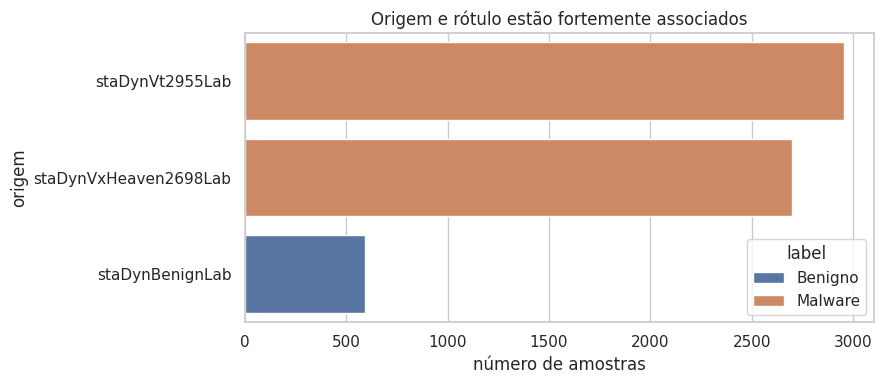

Proporção de malware: 90.5%


In [ ]:
plt.figure(figsize=(9, 4))
ordem = df['source_dataset'].value_counts().index
sns.countplot(data=df, y='source_dataset', hue='label', order=ordem)
plt.title('Origem e rótulo estão fortemente associados')
plt.xlabel('número de amostras')
plt.ylabel('origem')
plt.legend(title='label', labels=['Benigno', 'Malware'])
plt.tight_layout()
plt.show()

print('Proporção de malware:', f"{df['label'].mean():.1%}")

## 3. Escolher features com significado

Em vez de entregar mais de mil colunas ao modelo, começaremos com um conjunto pequeno e auditável.

### Famílias escolhidas

- **Estrutura PE:** tamanho, número de seções, entry point e alinhamentos.
- **Entropia e seções:** entropia e tamanho de regiões conhecidas.
- **Imports/capacidades:** presença de APIs ligadas a memória, processos, rede e registro.

Uma API isolada não prova que um arquivo é malicioso. O modelo deve combinar sinais.

In [ ]:
features_estrutura = [
    'filesize', 'number_of_sections', 'size_code', 'size_init_data',
    'size_uninit_data', 'size_of_headers', 'size_of_optional_header',
    'AddressOfEntryPoint', 'image_base', 'section_alignment', 'file_alignment'
]

features_entropia = [
    'sec_entropy_data', 'sec_entropy_rdata', 'sec_entropy_reloc',
    'sec_entropy_text', 'sec_entropy_rsrc',
    'sec_rawsize_data', 'sec_rawsize_text'
]

features_imports = [
    'imported_dll_freq', 'number_of_import_symbols',
    'VirtualAlloc', 'VirtualProtect', 'WriteProcessMemory',
    'CreateRemoteThread', 'OpenProcess', 'RegSetValueExA',
    'InternetOpenA', 'URLDownloadToFileA'
]

features = features_estrutura + features_entropia + features_imports
ausentes = [c for c in features if c not in df.columns]
assert not ausentes, f'Features ausentes: {ausentes}'

X = df[features].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['label']

print(f'{len(features)} features selecionadas de {len(colunas_comuns)} colunas comuns.')
X.head()

28 features selecionadas de 1085 colunas comuns.


,filesize,number_of_sections,size_code,size_init_data,size_uninit_data,size_of_headers,size_of_optional_header,AddressOfEntryPoint,image_base,section_alignment,...,imported_dll_freq,number_of_import_symbols,VirtualAlloc,VirtualProtect,WriteProcessMemory,CreateRemoteThread,OpenProcess,RegSetValueExA,InternetOpenA,URLDownloadToFileA
0,57434,0,10752,10240,0,1024,224,12810,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0
1,44420,0,8192,8192,0,1024,224,10505,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0
2,20706,0,3072,8704,0,1024,224,5442,16777216.0,4096,...,0,0,0,0,0,0,0,0,0,0
3,69110,0,19456,10752,0,1024,224,19525,16777216.0,4096,...,0,0,0,0,0,0,0,0,0,0
4,39574,0,8192,7168,0,1024,224,9788,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0


## 4. Exploração orientada por hipóteses

Vamos criar uma feature agregada apenas para visualização: a média das entropias das seções conhecidas. Ela não substitui as entropias individuais no modelo.

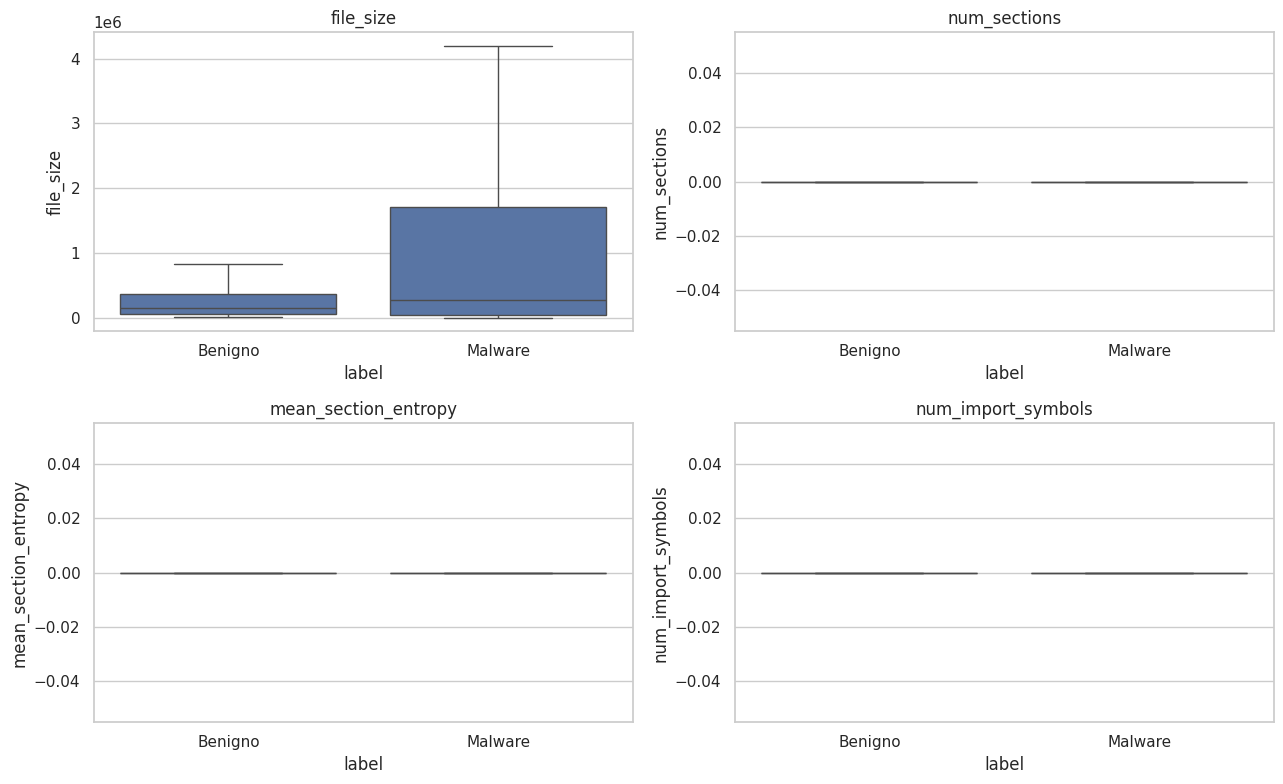

In [ ]:
cols_entropia = [c for c in features_entropia if c.startswith('sec_entropy_')]
eda = pd.DataFrame({
    'label': y.map({0: 'Benigno', 1: 'Malware'}),
    'file_size': X['filesize'],
    'num_sections': X['number_of_sections'],
    'mean_section_entropy': X[cols_entropia].mean(axis=1),
    'num_import_symbols': X['number_of_import_symbols']
})

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, coluna in zip(axes.ravel(), eda.columns[1:]):
    sns.boxplot(data=eda, x='label', y=coluna, ax=ax, showfliers=False)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

### Discussão rápida

- Quais features parecem separar as classes?
- Essa diferença pode ser causada pela forma de coleta?
- Qual delas seria fácil para um atacante manipular?
- Ausência de um import significa ausência daquela capacidade?

### Respostas da equipe (Maria Clara Miranda e Evandro José)

**1) Quais features parecem separar as classes?**
Só `file_size` mostra diferença real entre as classes: malwares tendem a ser bem maiores e mais variáveis (mediana em torno de 280 KB, chegando a 4,2 MB) do que benignos (mediana em torno de 150 KB, raramente passando de 800 KB). As outras três features do gráfico (`num_sections`, `mean_section_entropy`, `num_import_symbols`) aparecem completamente zeradas nos dois grupos — não porque não há diferença real entre malware e benigno nesses aspectos, mas porque os dados dessas colunas parecem estar ausentes/zerados nesse recorte do dataset.

**2) Essa diferença pode ser causada pela forma de coleta?**
Muito provavelmente sim. O próprio notebook já alertou (célula 8) que `source_dataset` determina quase perfeitamente o rótulo. É plausível que benignos e malwares venham de gerações diferentes de compiladores, empacotadores ou métodos de build, o que infla `file_size` de forma artificial — não porque "ser malware" causa arquivos maiores, mas porque a pipeline de coleta é diferente.

**3) Qual seria fácil para um atacante manipular?**
`file_size` (e, por extensão, `size_code`, `size_init_data`, `size_of_headers`) — um atacante pode inflar o binário com padding (bytes de lixo) ou compactar/empacotar de forma diferente, mudando o tamanho sem alterar em nada o comportamento malicioso real.

**4) Ausência de um import significa ausência daquela capacidade?**
Não. Um malware pode resolver APIs dinamicamente em tempo de execução (via `LoadLibrary` + `GetProcAddress`) ou estar empacotado/ofuscado, de forma que a tabela de imports estática não mostre `VirtualAlloc` ou `WriteProcessMemory` mesmo que o binário use essas funções depois de descompactado na memória. Ausência na análise estática não é o mesmo que ausência da capacidade real.

## 5. Separar treino, validação e teste

O teste será usado **uma única vez**, depois que o modelo e o limiar estiverem definidos.

- treino: 60%;
- validação: 20%;
- teste: 20%.

Usamos estratificação porque a classe malware é majoritária.

In [ ]:
X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X_treino_val, y_treino_val, test_size=0.25,
    stratify=y_treino_val, random_state=RANDOM_SEED
)

print('Treino   :', X_treino.shape, 'malware:', f'{y_treino.mean():.1%}')
print('Validação:', X_valid.shape,  'malware:', f'{y_valid.mean():.1%}')
print('Teste    :', X_teste.shape,  'malware:', f'{y_teste.mean():.1%}')

Treino   : (3748, 28) malware: 90.5%
Validação: (1250, 28) malware: 90.5%
Teste    : (1250, 28) malware: 90.5%


## 6. Baseline: prever sempre a classe majoritária

Como malware é majoritário, um modelo que sempre responde “malware” pode ter acurácia alta. O baseline revela quanto o modelo precisa superar.

In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_treino, y_treino)
pred_dummy = dummy.predict(X_valid)

print(classification_report(y_valid, pred_dummy, target_names=['Benigno', 'Malware'], zero_division=0))
print('O baseline detecta malware, mas bloqueia todos os benignos.')

              precision    recall  f1-score   support

     Benigno       0.00      0.00      0.00       119
     Malware       0.90      1.00      0.95      1131

    accuracy                           0.90      1250
   macro avg       0.45      0.50      0.48      1250
weighted avg       0.82      0.90      0.86      1250

O baseline detecta malware, mas bloqueia todos os benignos.


## 7. Treinar o Random Forest

Usamos pesos balanceados para evitar que a classe majoritária domine as árvores. O foco ainda não é otimizar hiperparâmetros.

In [ ]:
modelo = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
modelo.fit(X_treino, y_treino)

proba_valid = modelo.predict_proba(X_valid)[:, 1]
pred_valid_05 = (proba_valid >= 0.50).astype(int)

print(classification_report(y_valid, pred_valid_05, target_names=['Benigno', 'Malware']))
print('ROC-AUC:', f'{roc_auc_score(y_valid, proba_valid):.3f}')
print('PR-AUC :', f'{average_precision_score(y_valid, proba_valid):.3f}')

              precision    recall  f1-score   support

     Benigno       0.61      0.83      0.70       119
     Malware       0.98      0.94      0.96      1131

    accuracy                           0.93      1250
   macro avg       0.80      0.89      0.83      1250
weighted avg       0.95      0.93      0.94      1250

ROC-AUC: 0.960
PR-AUC : 0.995


## 8. Matriz de confusão na validação

Neste contexto:

- **falso negativo:** malware classificado como benigno;
- **falso positivo:** programa benigno classificado como malware.

Um antivírus precisa controlar os dois: deixar malware passar é perigoso, mas bloquear software legítimo também pode interromper a operação.

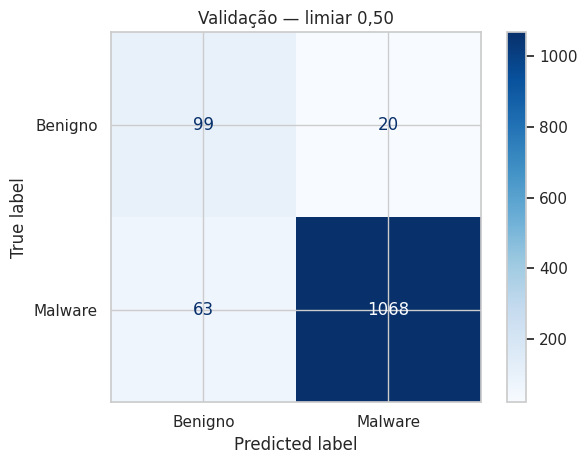

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_valid, pred_valid_05,
    display_labels=['Benigno', 'Malware'], cmap='Blues'
)
plt.title('Validação — limiar 0,50')
plt.tight_layout()
plt.show()

## 9. Escolher o limiar usando apenas a validação

Vamos procurar o menor limiar que alcance **recall de malware ≥ 95%** e, entre os candidatos, escolher aquele com maior precisão.

Essa regra é uma decisão didática. Em produção, o alvo deve vir do custo e da capacidade do SOC.

Limiar escolhido na validação: 0.46


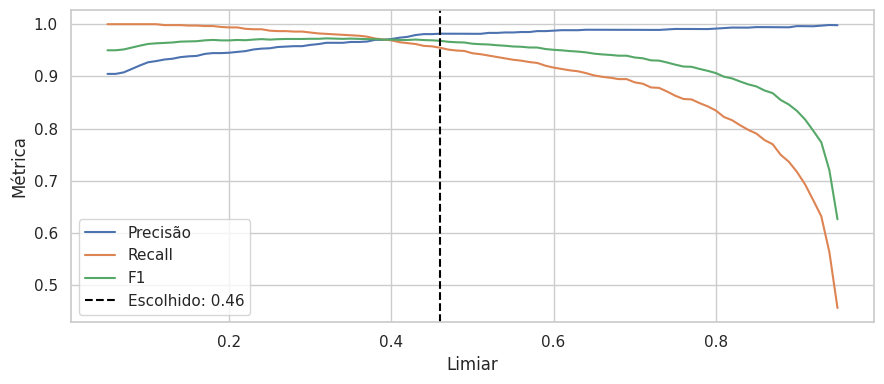

In [ ]:
linhas = []
for limiar in np.arange(0.05, 0.96, 0.01):
    pred = (proba_valid >= limiar).astype(int)
    linhas.append({
        'limiar': limiar,
        'precisao': precision_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred),
        'f1': f1_score(y_valid, pred)
    })

tabela_lim = pd.DataFrame(linhas)
candidatos = tabela_lim[tabela_lim['recall'] >= 0.95]
if len(candidatos):
    LIMIAR = candidatos.sort_values(['precisao', 'limiar'], ascending=[False, False]).iloc[0]['limiar']
else:
    LIMIAR = tabela_lim.loc[tabela_lim['f1'].idxmax(), 'limiar']

print('Limiar escolhido na validação:', round(float(LIMIAR), 2))

plt.figure(figsize=(9, 4))
plt.plot(tabela_lim['limiar'], tabela_lim['precisao'], label='Precisão')
plt.plot(tabela_lim['limiar'], tabela_lim['recall'], label='Recall')
plt.plot(tabela_lim['limiar'], tabela_lim['f1'], label='F1')
plt.axvline(LIMIAR, color='black', ls='--', label=f'Escolhido: {LIMIAR:.2f}')
plt.xlabel('Limiar')
plt.ylabel('Métrica')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Avaliação final — agora podemos abrir o teste

Depois desta célula, não altere o modelo ou o limiar com base no resultado do teste. Se alterarmos, o teste deixa de ser independente.

Limiar: 0.46
              precision    recall  f1-score   support

     Benigno       0.72      0.82      0.76       119
     Malware       0.98      0.97      0.97      1131

    accuracy                           0.95      1250
   macro avg       0.85      0.89      0.87      1250
weighted avg       0.96      0.95      0.95      1250

ROC-AUC: 0.972
PR-AUC : 0.997


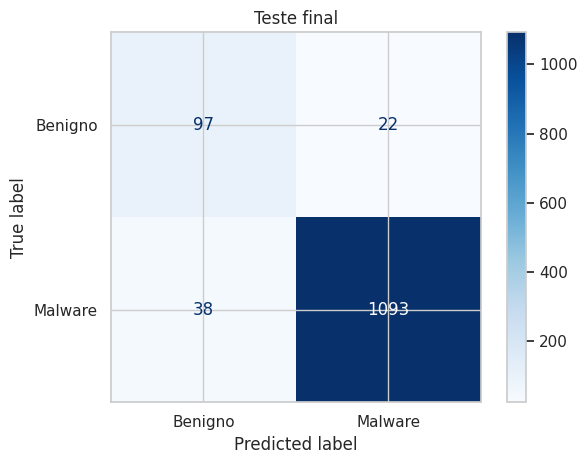

In [ ]:
proba_teste = modelo.predict_proba(X_teste)[:, 1]
pred_teste = (proba_teste >= LIMIAR).astype(int)

print('Limiar:', round(float(LIMIAR), 2))
print(classification_report(y_teste, pred_teste, target_names=['Benigno', 'Malware']))
print('ROC-AUC:', f'{roc_auc_score(y_teste, proba_teste):.3f}')
print('PR-AUC :', f'{average_precision_score(y_teste, proba_teste):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_teste, pred_teste,
    display_labels=['Benigno', 'Malware'], cmap='Blues'
)
plt.title('Teste final')
plt.tight_layout()
plt.show()

## 11. Quais features o modelo utilizou?

A importância do Random Forest indica quanto uma feature ajudou as árvores a reduzir impureza.

> **Importância não é causalidade.** Uma feature importante pode representar viés de coleta ou uma regularidade fácil de evadir.

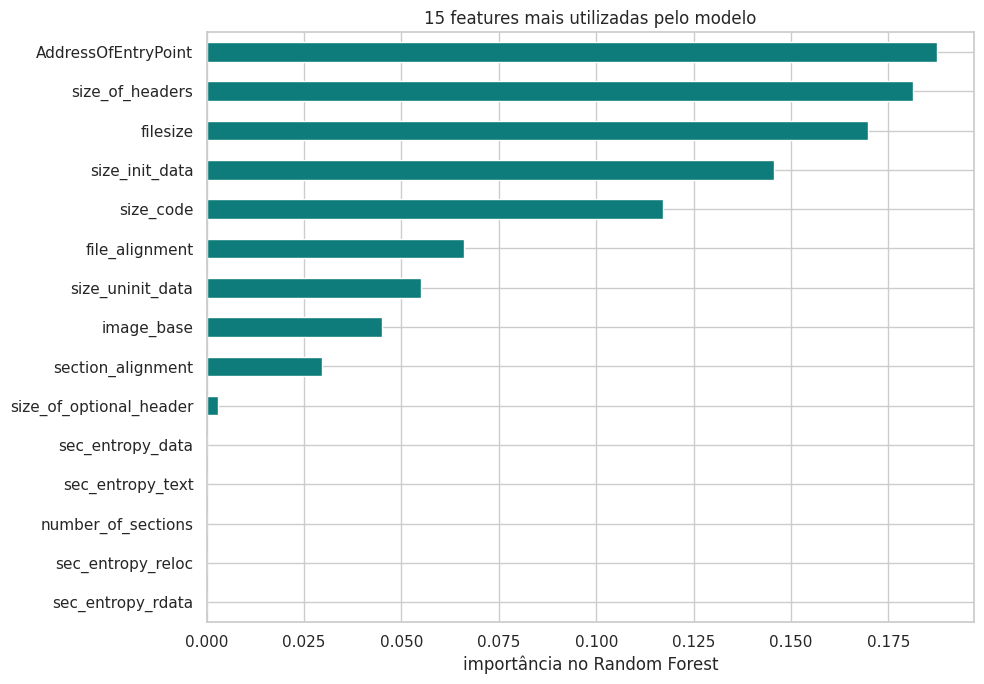

,importancia
AddressOfEntryPoint,0.187579
size_of_headers,0.181206
filesize,0.169679
size_init_data,0.145645
size_code,0.117251
file_alignment,0.066138
size_uninit_data,0.054983
image_base,0.045012
section_alignment,0.029676
size_of_optional_header,0.002831


In [ ]:
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importancias.head(15).sort_values().plot(kind='barh', color='#0E7C7B')
plt.title('15 features mais utilizadas pelo modelo')
plt.xlabel('importância no Random Forest')
plt.tight_layout()
plt.show()

importancias.head(15).to_frame('importancia')

### Perguntas para discussão

- As features do topo fazem sentido para malware?
- Alguma pode denunciar o ambiente ou a fonte de coleta?
- O que aconteceria se o atacante alterasse apenas essa feature?
- Duas features parecidas podem dividir importância entre si?

### Respostas da equipe (Maria Clara Miranda e Evandro José)

**1) As features do topo fazem sentido para malware?**
Fazem sentido parcial. `AddressOfEntryPoint` anômalo e tamanhos de seção/cabeçalho fora do padrão são sinais clássicos de packers e ofuscadores usados por malware. Mas é um alerta que o modelo não esteja usando nenhuma feature de entropia ou de imports (capacidades comportamentais) — a tabela de ablação (célula 31) mostra que os grupos "Entropia/seções" e "Imports/capacidades" ficam com recall médio de apenas 0,600, enquanto "Estrutura" sozinha já atinge 0,966. O ideal em segurança é que o modelo combine estrutura com comportamento, e aqui ele está decidindo quase só pela "forma" do arquivo.

**2) Alguma pode denunciar o ambiente ou a fonte de coleta?**
Sim, principalmente `filesize` e as features de tamanho de seção — como vimos na célula 9, a origem do arquivo (`source_dataset`) está fortemente associada ao rótulo. É provável que essas features de tamanho estejam carregando a assinatura de "como o arquivo foi empacotado/coletado" em vez de "é malicioso ou não", reforçando o viés de origem já identificado no início do notebook.

**3) O que aconteceria se o atacante alterasse apenas essa feature?**
Como as 5 features mais importantes são todas estruturais e superficiais (tamanho de arquivo, offset do entry point, tamanho de seções), um atacante conseguiria enganar esse modelo específico apenas fazendo padding, recompilando com flags diferentes ou realinhando seções — sem tocar no comportamento malicioso. É um caso claro de modelo vulnerável a evasão por manipulação de features fáceis de forjar.

**4) Duas features parecidas podem dividir importância entre si?**
Sim — `size_code`, `size_init_data`, `size_uninit_data` e `size_of_headers` são todas medidas de tamanho de partes do PE, altamente correlacionadas entre si. O Random Forest pode estar "diluindo" a importância entre elas, o que significa que o sinal real pode estar concentrado em menos dimensões independentes do que o gráfico sugere.

## 12. Ablação por famílias de features

Vamos comparar grupos de features usando validação cruzada somente no conjunto de treino + validação. O objetivo é avaliar quanto cada família contribui.

In [ ]:
grupos = {
    'Estrutura': features_estrutura,
    'Entropia/seções': features_entropia,
    'Imports/capacidades': features_imports,
    'Todas': features
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados = []

for nome, cols in grupos.items():
    m = RandomForestClassifier(
        n_estimators=150, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1,
        random_state=RANDOM_SEED
    )
    scores = cross_validate(
        m, X_treino_val[cols], y_treino_val,
        cv=cv, scoring={'recall': 'recall', 'f1': 'f1', 'pr_auc': 'average_precision'},
        n_jobs=-1
    )
    resultados.append({
        'grupo': nome,
        'recall_medio': scores['test_recall'].mean(),
        'f1_medio': scores['test_f1'].mean(),
        'pr_auc_media': scores['test_pr_auc'].mean()
    })

pd.DataFrame(resultados).set_index('grupo').round(3)

,recall_medio,f1_medio,pr_auc_media
grupo,,,
Estrutura,0.966,0.970,0.997
Entropia/seções,0.600,0.570,0.905
Imports/capacidades,0.600,0.570,0.905
Todas,0.951,0.964,0.996


## 13. Limitações que precisam acompanhar o resultado

1. **Viés de origem:** benignos e maliciosos foram coletados de fontes diferentes.
2. **Idade:** parte dos dados representa software e malware antigos.
3. **Split aleatório:** variantes próximas podem aparecer em treino e teste.
4. **Rótulo:** “malware” depende do processo de rotulagem usado pelos autores.
5. **Evasão:** um atacante pode alterar features estáticas sem mudar o comportamento.

Para um projeto mais robusto, use uma base temporal como BODMAS ou EMBER e faça divisão por tempo, família e campanha.

## 14. Exportar features para o Splunk (opcional)

Vamos produzir um CSV pequeno, sem hashes ou executáveis. Os nomes das colunas abaixo serão usados nos comandos SPL.

In [ ]:
splunk_df = pd.DataFrame({
    'sample_id': df['sample_id'],
    'label': df['label'].map({0: 'benign', 1: 'malicious'}),
    'file_size': pd.to_numeric(df['filesize'], errors='coerce').fillna(0),
    'entropy': df[cols_entropia].apply(pd.to_numeric, errors='coerce').fillna(0).mean(axis=1),
    'num_sections': pd.to_numeric(df['number_of_sections'], errors='coerce').fillna(0),
    'num_imports': pd.to_numeric(df['number_of_import_symbols'], errors='coerce').fillna(0),
    'size_code': pd.to_numeric(df['size_code'], errors='coerce').fillna(0),
    'entry_point': pd.to_numeric(df['AddressOfEntryPoint'], errors='coerce').fillna(0),
    'has_virtual_alloc': (pd.to_numeric(df['VirtualAlloc'], errors='coerce').fillna(0) > 0).astype(int),
    'has_write_process_memory': (pd.to_numeric(df['WriteProcessMemory'], errors='coerce').fillna(0) > 0).astype(int)
})

CAMINHO_SPLUNK = '/content/malware_features.csv'
splunk_df.to_csv(CAMINHO_SPLUNK, index=False)
print('Arquivo salvo em:', CAMINHO_SPLUNK)
print('Dimensões:', splunk_df.shape)
splunk_df.head()

Arquivo salvo em: /content/malware_features.csv
Dimensões: (6248, 10)


,sample_id,label,file_size,entropy,num_sections,num_imports,size_code,entry_point,has_virtual_alloc,has_write_process_memory
0,0,benign,57434,0.0,0,0,10752,12810,0,0
1,1,benign,44420,0.0,0,0,8192,10505,0,0
2,2,benign,20706,0.0,0,0,3072,5442,0,0
3,3,benign,69110,0.0,0,0,19456,19525,0,0
4,4,benign,39574,0.0,0,0,8192,9788,0,0


In [ ]:
# Baixar o CSV no navegador do Colab
try:
    from google.colab import files
    files.download(CAMINHO_SPLUNK)
except ImportError:
    print('Fora do Colab: arquivo disponível em', CAMINHO_SPLUNK)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. SPL correspondente no Splunk AI Toolkit (opcional)

Depois de enviar o arquivo como lookup:

### Treinar e salvar

```spl
| inputlookup malware_features.csv
| sample partitions=100 seed=42
| search partition_number<=70
| fit RandomForestClassifier label from file_size entropy num_sections num_imports size_code entry_point has_virtual_alloc has_write_process_memory into malware_rf_v1
```

### Aplicar no teste

```spl
| inputlookup malware_features.csv
| sample partitions=100 seed=42
| search partition_number>70
| apply malware_rf_v1 as predicao
| `confusionmatrix(label, predicao)`
```

> O split com `sample` é adequado para a demonstração. Em produção, carregue uma coluna de tempo/campanha e preserve o futuro como teste.

## Entregável da aula

- [x] Base real carregada e origem dos dados documentada.
- [x] Conjunto de features justificado por famílias.
- [x] Treino, validação e teste separados antes da modelagem.
- [x] Baseline e Random Forest comparados.
- [x] Limiar escolhido somente na validação.
- [x] Teste final executado uma única vez.
- [x] Importâncias e riscos de leakage discutidos.
- [x] Respostas das perguntas registradas no notebook.